In [28]:
# ── BLOCK 1: IMPORTS & CONFIG ─────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

import yfinance as yf
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

TICKER         = 'SPY'
START_DATE     = '1993-01-01'
MACRO_TICKERS  = ['^VIX', '^TNX', 'GLD', 'TLT', 'QQQ']
FORWARD_DAYS   = 7
N_SPLITS       = 5
N_TRIALS_MODEL = 150
N_TRIALS_CONF  = 100
MIN_PCT_INV    = 0.30
RANDOM_STATE   = 42

In [29]:

# ── BLOCK 2: DATA DOWNLOAD & MERGE ────────────────────────────────────────────
def download_clean(ticker, start):
    raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.droplevel(1)
    raw.index = pd.to_datetime(raw.index)
    return raw

spy = download_clean(TICKER, START_DATE)[['Open', 'High', 'Low', 'Close', 'Volume']]

macro_frames = {}
for t in MACRO_TICKERS:
    col = t.replace('^', '')
    try:
        d = download_clean(t, START_DATE)[['Close']].rename(columns={'Close': col})
        macro_frames[col] = d
        print(f"  ✓ {t}: {len(d)} rows")
    except Exception as e:
        print(f"  ✗ {t}: {e}")

df = spy.copy()
for name, mdf in macro_frames.items():
    df = df.join(mdf, how='left')

df = df.ffill().dropna(subset=['Close'])
print(f"\nMerged shape : {df.shape}")
print(f"Date range   : {df.index[0].date()} → {df.index[-1].date()}")


  ✓ ^VIX: 8358 rows
  ✓ ^TNX: 8336 rows
  ✓ GLD: 5364 rows
  ✓ TLT: 5946 rows
  ✓ QQQ: 6797 rows

Merged shape : (8339, 10)
Date range   : 1993-01-29 → 2026-03-17


In [30]:

# ── BLOCK 3: FEATURE ENGINEERING ──────────────────────────────────────────────
def rsi(series: pd.Series, period: int) -> pd.Series:
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - 100 / (1 + gain / (loss + 1e-9))

def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.DataFrame(index=df.index)
    C, H, L, O, V = df['Close'], df['High'], df['Low'], df['Open'], df['Volume']

    # ── Candlestick
    f['range']        = (H - L) / C
    f['body']         = (C - O) / C
    f['upper_shadow'] = (H - np.maximum(C, O)) / C
    f['lower_shadow'] = (np.minimum(C, O) - L) / C
    f['gap']          = (O - C.shift(1)) / C.shift(1)

    # ── Returns / Momentum multi-timeframe
    for p in [1, 5, 10, 21, 63]:
        f[f'ret_{p}d'] = C.pct_change(p)

    # ── Moving Averages & crosses
    ma = {w: C.rolling(w).mean() for w in [5, 21, 50, 200]}
    for w, m in ma.items():
        f[f'dist_ma{w}'] = (C - m) / m          # price distance normalised
    f['cross_ma5_21']  = (ma[5]  - ma[21])  / C
    f['cross_ma21_50'] = (ma[21] - ma[50])   / C

    # ── Regime (bool features)
    f['above_ma50']  = (C > ma[50]).astype(int)
    f['above_ma200'] = (C > ma[200]).astype(int)

    # ── Volatility
    ret1 = C.pct_change()
    for w in [5, 10, 21]:
        f[f'vol_{w}d'] = ret1.rolling(w).std() * np.sqrt(252)

    TR = pd.concat(
        [(H - L), (H - C.shift(1)).abs(), (L - C.shift(1)).abs()], axis=1
    ).max(axis=1)
    f['atr14'] = TR.rolling(14).mean() / C

    bb_mid, bb_std = C.rolling(20).mean(), C.rolling(20).std()
    f['bb_pos']   = (C - (bb_mid - 2*bb_std)) / (4*bb_std + 1e-9)
    f['bb_width'] = 4*bb_std / bb_mid

    # ── Oscillators
    f['rsi7']  = rsi(C, 7)  / 100
    f['rsi14'] = rsi(C, 14) / 100

    ema12, ema26 = C.ewm(span=12, adjust=False).mean(), C.ewm(span=26, adjust=False).mean()
    macd         = ema12 - ema26
    macd_sig     = macd.ewm(span=9, adjust=False).mean()
    f['macd']      = macd              / C
    f['macd_sig']  = macd_sig          / C
    f['macd_hist'] = (macd - macd_sig) / C

    lo14, hi14 = L.rolling(14).min(), H.rolling(14).max()
    sk = 100 * (C - lo14) / (hi14 - lo14 + 1e-9)
    f['stoch_k'] = sk.rolling(3).mean() / 100
    f['stoch_d'] = f['stoch_k'].rolling(3).mean()

    # ── Volume
    obv = (np.sign(ret1) * V).fillna(0).cumsum()
    f['obv_ratio']  = obv / (obv.rolling(20).mean() + 1e-9)
    f['vol_ratio5'] = V   / (V.rolling(5).mean()    + 1e-9)

    # ── Macro (per ogni asset esterno)
    for col in ['VIX', 'TNX', 'GLD', 'TLT', 'QQQ']:
        if col not in df.columns:
            continue
        s = df[col]
        ma20 = s.rolling(20).mean()
        f[f'{col.lower()}_ret1']    = s.pct_change(1)
        f[f'{col.lower()}_ret5']    = s.pct_change(5)
        f[f'{col.lower()}_ret21']   = s.pct_change(21)
        f[f'{col.lower()}_vs_ma20'] = (s - ma20) / (ma20 + 1e-9)

    if 'VIX' in df.columns:
        vix = df['VIX']
        f['vix_spike']  = vix / (vix.rolling(20).mean() + 1e-9) - 1
        f['vix_change'] = vix.pct_change(1)
        f['vix_regime'] = (vix > 20).astype(int)

    # ── Seasonality
    f['month']          = df.index.month
    f['weekday']        = df.index.dayofweek
    f['month_progress'] = df.index.day / df.index.days_in_month

    return f

features = compute_features(df)
print(f"Features : {features.shape[1]} cols × {features.shape[0]} rows")


Features : 59 cols × 8339 rows


In [31]:
# ── BLOCK 4: TARGET & DATASET ASSEMBLY ────────────────────────────────────────
fwd_ret = df['Close'].pct_change(FORWARD_DAYS).shift(-FORWARD_DAYS)
target  = (fwd_ret > 0).astype(int).rename('target')

dataset = features.join(target).dropna()
dataset = dataset[dataset.index >= '1995-01-01']    # attendi warmup MA200

X     = dataset.drop(columns=['target'])
y     = dataset['target']
dates = dataset.index

print(f"Dataset    : {X.shape}")
print(f"Positive % : {y.mean():.1%}  (baseline always-long accuracy)")
print(f"Date range : {dates[0].date()} → {dates[-1].date()}")

Dataset    : (5343, 59)
Positive % : 61.2%  (baseline always-long accuracy)
Date range : 2004-12-20 → 2026-03-17


In [32]:

# ── BLOCK 5: LIGHTGBM HYPERPARAMETER OPTIMIZATION (OPTUNA + TimeSeriesSplit) ──
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

def lgbm_objective(trial):
    params = dict(
        objective         = 'binary',
        metric            = 'binary_logloss',
        verbosity         = -1,
        n_estimators      = trial.suggest_int('n_estimators',       200, 1200),
        learning_rate     = trial.suggest_float('learning_rate',    0.005, 0.1, log=True),
        num_leaves        = trial.suggest_int('num_leaves',         16, 256),
        max_depth         = trial.suggest_int('max_depth',          3, 12),
        min_child_samples = trial.suggest_int('min_child_samples',  20, 300),
        subsample         = trial.suggest_float('subsample',        0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha',        1e-4, 10., log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',       1e-4, 10., log=True),
        min_split_gain    = trial.suggest_float('min_split_gain',   0.0, 1.0),
        random_state      = RANDOM_STATE,
    )
    scores = []
    for tr_idx, val_idx in tscv.split(X):
        mdl = lgb.LGBMClassifier(**params)
        mdl.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        scores.append(accuracy_score(y.iloc[val_idx], mdl.predict(X.iloc[val_idx])))
    return np.mean(scores)

study_model = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
)
study_model.optimize(lgbm_objective, n_trials=N_TRIALS_MODEL, show_progress_bar=True)

BEST_PARAMS = {
    **study_model.best_params,
    'objective': 'binary', 'metric': 'binary_logloss',
    'verbosity': -1, 'random_state': RANDOM_STATE
}
print(f"\nBest CV Accuracy : {study_model.best_value:.4f}")
print(f"Best params      : {BEST_PARAMS}")

Best trial: 140. Best value: 0.622472: 100%|██████████| 150/150 [01:08<00:00,  2.19it/s]


Best CV Accuracy : 0.6225
Best params      : {'n_estimators': 710, 'learning_rate': 0.06958175386155663, 'num_leaves': 95, 'max_depth': 5, 'min_child_samples': 25, 'subsample': 0.6025546660691965, 'colsample_bytree': 0.6395105617842971, 'reg_alpha': 1.68163121976506, 'reg_lambda': 0.00010962244575997803, 'min_split_gain': 0.008105197608719542, 'objective': 'binary', 'metric': 'binary_logloss', 'verbosity': -1, 'random_state': 42}


In [33]:
# ── BLOCK 6: TRAIN FINAL MODEL — 70/30 TEMPORAL SPLIT ────────────────────────
split = int(len(X) * 0.70)
X_train, X_test = X.iloc[:split],  X.iloc[split:]
y_train, y_test = y.iloc[:split],  y.iloc[split:]
dates_test      = dates[split:]

model = lgb.LGBMClassifier(**BEST_PARAMS)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

prob_up = model.predict_proba(X_test)[:, 1]
acc     = accuracy_score(y_test, (prob_up > 0.5).astype(int))
print(f"OOS Accuracy (thresh=0.5) : {acc:.4f}")
print(f"Test period               : {dates_test[0].date()} → {dates_test[-1].date()} ({len(X_test)} days)")




OOS Accuracy (thresh=0.5) : 0.6188
Test period               : 2019-10-29 → 2026-03-17 (1603 days)


In [34]:

# ── BLOCK 7: CONFIDENCE THRESHOLD OPTIMIZATION (OPTUNA) ──────────────────────
spy_rets_arr = df.loc[dates_test, 'Close'].pct_change().fillna(0).values

def strategy_metrics(prob, spy_r, conf):
    pos = np.where(prob > conf, prob, 0.0)
    pos = np.roll(pos, 1); pos[0] = 0.0         # 1-day execution lag (no lookahead)
    sr  = pos * spy_r
    pct = np.mean(pos > 0)
    if pct < MIN_PCT_INV:
        return -np.inf, pct
    sharpe = (np.nanmean(sr) / (np.nanstd(sr) + 1e-9)) * np.sqrt(252)
    return sharpe, pct

def conf_objective(trial):
    c = trial.suggest_float('conf', 0.50, 0.75)
    sh, pct = strategy_metrics(prob_up, spy_rets_arr, c)
    if pct < 0.40 or pct > 0.75:      
        return -np.inf
    return sh

study_conf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_conf.optimize(conf_objective, n_trials=N_TRIALS_CONF, show_progress_bar=True)

CONF = study_conf.best_params['conf']
sh_opt, pct_opt = strategy_metrics(prob_up, spy_rets_arr, CONF)
print(f"\nOptimal CONF    : {CONF:.4f}")
print(f"Sharpe (OOS)    : {sh_opt:.4f}")
print(f"% investito     : {pct_opt:.1%}")


Best trial: 77. Best value: 1.32165: 100%|██████████| 100/100 [00:00<00:00, 314.95it/s]


Optimal CONF    : 0.6122
Sharpe (OOS)    : 1.3217
% investito     : 42.2%


In [35]:
# ── BLOCK 8: BACKTEST ─────────────────────────────────────────────────────────
def backtest(prob, close_series, conf):
    rets  = close_series.pct_change().fillna(0).values
    pos   = np.where(prob > conf, prob, 0.0)
    pos   = np.roll(pos, 1); pos[0] = 0.0

    sr  = pos * rets
    bh  = rets

    eq_s = np.cumprod(1 + sr)
    eq_b = np.cumprod(1 + bh)

    def sharpe(r): return (np.nanmean(r) / (np.nanstd(r) + 1e-9)) * np.sqrt(252)
    def mdd(eq):   return ((eq - np.maximum.accumulate(eq)) / np.maximum.accumulate(eq)).min()

    active = sr[pos > 0]
    metrics = {
        'Return Strategy' : eq_s[-1] - 1,
        'Return B&H'      : eq_b[-1] - 1,
        'Sharpe Strategy' : sharpe(sr),
        'Sharpe B&H'      : sharpe(bh),
        'MDD Strategy'    : mdd(eq_s),
        'MDD B&H'         : mdd(eq_b),
        'Hit Rate'        : float(np.mean(active > 0)) if len(active) else 0.,
        'Pct Invested'    : float(np.mean(pos > 0)),
        'N Switches'      : int(np.sum(np.diff((pos > 0).astype(int)) != 0)),
    }
    return metrics, eq_s, eq_b, sr, bh, pos

close_test = df.loc[dates_test, 'Close']
M, eq_s, eq_b, sr, bh, pos = backtest(prob_up, close_test, CONF)

print("\n" + "═"*52)
print("  BACKTEST RESULTS — OOS TEST SET")
print("═"*52)
for k, v in M.items():
    if 'Return' in k or 'MDD' in k:
        print(f"  {k:<26s}: {v:+.2%}")
    elif isinstance(v, float):
        print(f"  {k:<26s}: {v:.4f}")
    else:
        print(f"  {k:<26s}: {v}")

sh_tgt  = M['Sharpe B&H'] * 0.875
mdd_tgt = M['MDD B&H']    * 0.775       # miglioramento MDD ≥ 22.5%
print(f"\n  Sharpe target >= {sh_tgt:.4f}  → {'✓ PASS' if M['Sharpe Strategy'] >= sh_tgt  else '✗ FAIL'}")
print(f"  MDD    target >= {mdd_tgt:.2%} → {'✓ PASS' if M['MDD Strategy']    >= mdd_tgt else '✗ FAIL'}")




════════════════════════════════════════════════════
  BACKTEST RESULTS — OOS TEST SET
════════════════════════════════════════════════════
  Return Strategy           : +81.19%
  Return B&H                : +142.61%
  Sharpe Strategy           : 1.3217
  Sharpe B&H                : 0.7896
  MDD Strategy              : -8.94%
  MDD B&H                   : -33.72%
  Hit Rate                  : 0.5858
  Pct Invested              : 0.4217
  N Switches                : 410

  Sharpe target >= 0.6909  → ✓ PASS
  MDD    target >= -26.13% → ✓ PASS


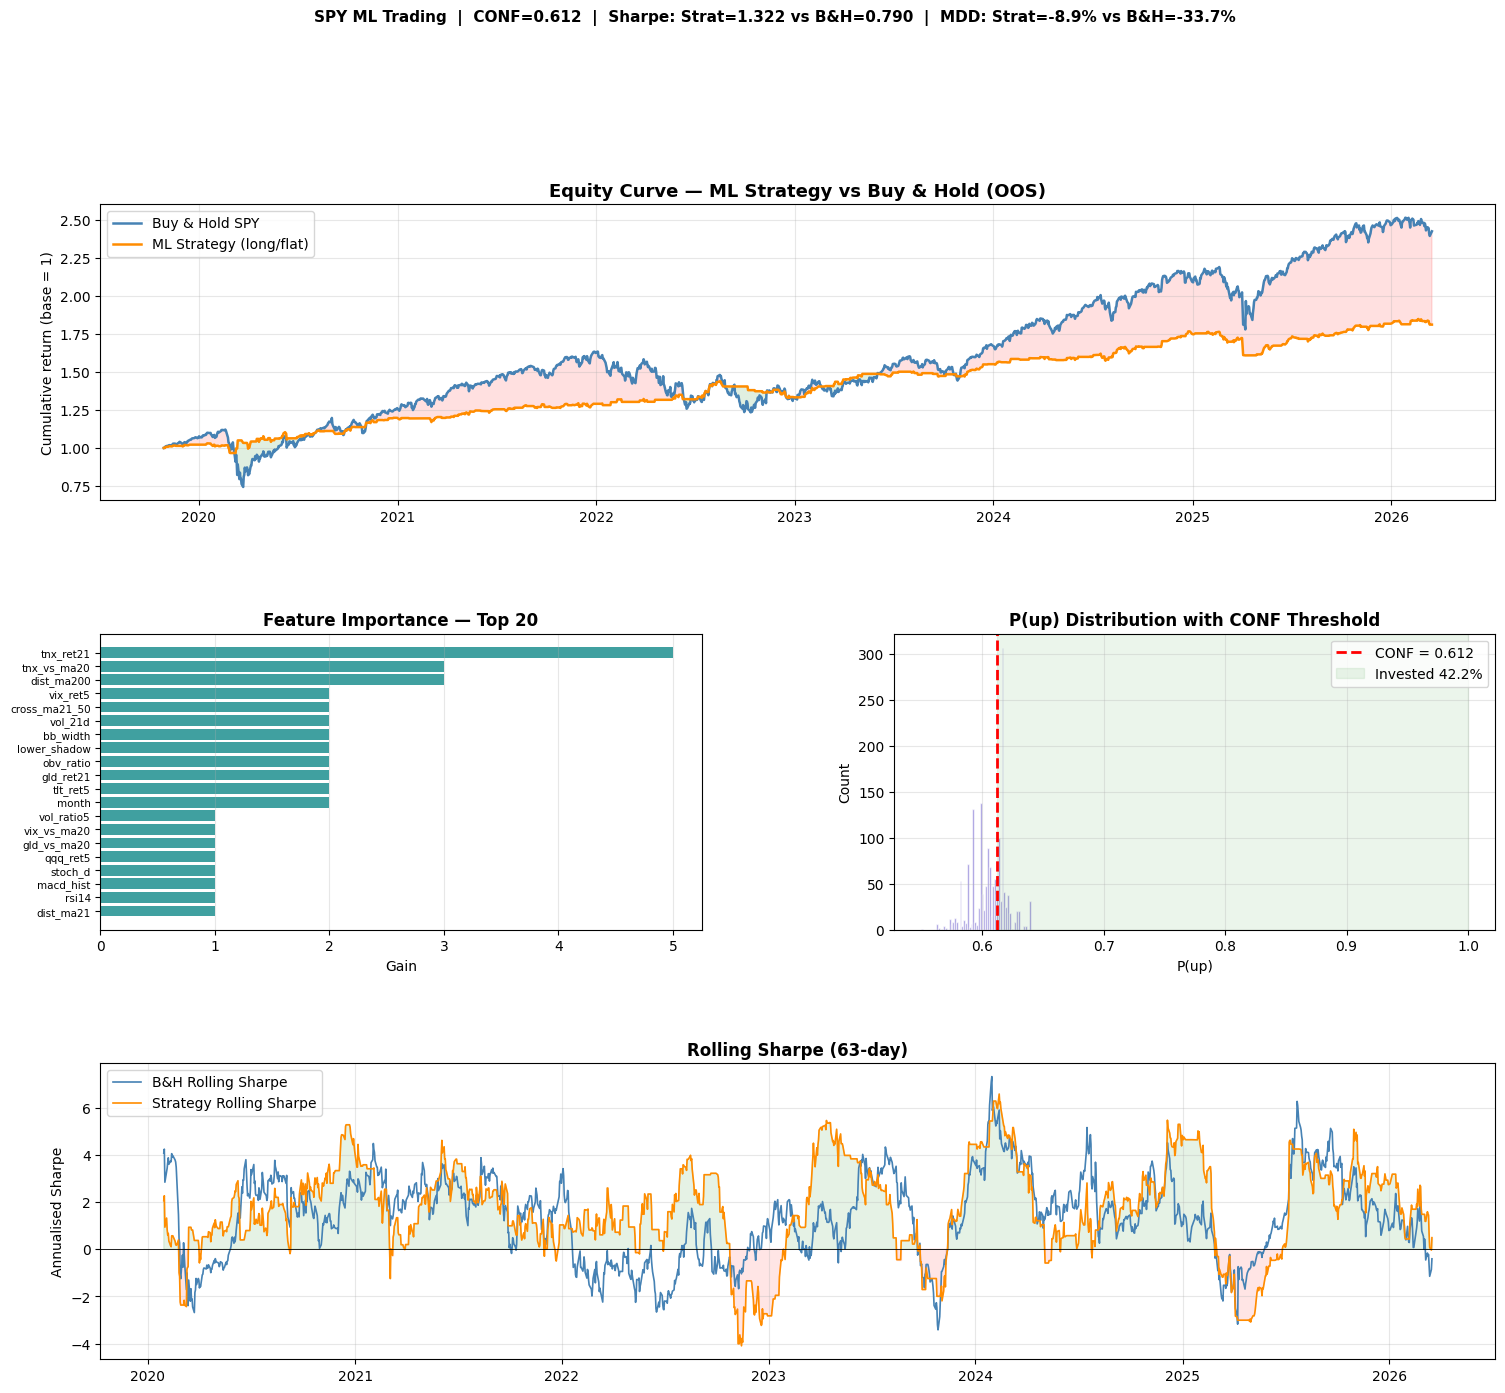

Saved → spy_ml_strategy.png


In [36]:

# ── BLOCK 9: VISUALISATION ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 15))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.32)
td  = pd.to_datetime(dates_test)

# ① Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(td, eq_b, lw=1.8, color='steelblue',  label='Buy & Hold SPY')
ax1.plot(td, eq_s, lw=1.8, color='darkorange',  label='ML Strategy (long/flat)')
ax1.fill_between(td, eq_s, eq_b, where=(eq_s >= eq_b), alpha=0.12, color='green')
ax1.fill_between(td, eq_s, eq_b, where=(eq_s <  eq_b), alpha=0.12, color='red')
ax1.set_title('Equity Curve — ML Strategy vs Buy & Hold (OOS)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Cumulative return (base = 1)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.legend(); ax1.grid(alpha=0.3)

# ② Feature importance top 20
ax2 = fig.add_subplot(gs[1, 0])
fi  = pd.Series(model.feature_importances_, index=X.columns).nlargest(20).sort_values()
ax2.barh(fi.index, fi.values, color='teal', alpha=0.75)
ax2.set_title('Feature Importance — Top 20', fontweight='bold')
ax2.set_xlabel('Gain'); ax2.tick_params(axis='y', labelsize=7.5)
ax2.grid(axis='x', alpha=0.3)

# ③ Signal distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(prob_up, bins=60, color='slateblue', alpha=0.7, edgecolor='white')
ax3.axvline(CONF, color='red', lw=2, ls='--', label=f'CONF = {CONF:.3f}')
ax3.axvspan(CONF, 1.0, alpha=0.08, color='green', label=f'Invested {np.mean(prob_up > CONF):.1%}')
ax3.set_title('P(up) Distribution with CONF Threshold', fontweight='bold')
ax3.set_xlabel('P(up)'); ax3.set_ylabel('Count')
ax3.legend(); ax3.grid(alpha=0.3)

# ④ Rolling Sharpe 63-day
ax4 = fig.add_subplot(gs[2, :])
W   = 63
roll_fn = lambda r: pd.Series(r).rolling(W).apply(
    lambda x: (x.mean() / (x.std() + 1e-9)) * np.sqrt(252), raw=True).values
rs_strat, rs_bh = roll_fn(sr), roll_fn(bh)
ax4.plot(td, rs_bh,    lw=1.2, color='steelblue',  label='B&H Rolling Sharpe')
ax4.plot(td, rs_strat, lw=1.2, color='darkorange',  label='Strategy Rolling Sharpe')
ax4.axhline(0, color='black', lw=0.6)
ax4.fill_between(td, rs_strat, 0, where=(rs_strat > 0), alpha=0.10, color='green')
ax4.fill_between(td, rs_strat, 0, where=(rs_strat < 0), alpha=0.10, color='red')
ax4.set_title(f'Rolling Sharpe ({W}-day)', fontweight='bold')
ax4.set_ylabel('Annualised Sharpe'); ax4.legend()
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.grid(alpha=0.3)

fig.suptitle(
    f"SPY ML Trading  |  CONF={CONF:.3f}  |  "
    f"Sharpe: Strat={M['Sharpe Strategy']:.3f} vs B&H={M['Sharpe B&H']:.3f}  |  "
    f"MDD: Strat={M['MDD Strategy']:+.1%} vs B&H={M['MDD B&H']:+.1%}",
    fontsize=11, fontweight='bold', y=1.01
)
plt.savefig('spy_ml_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → spy_ml_strategy.png")


Features SHAP-selected: 19 / 59


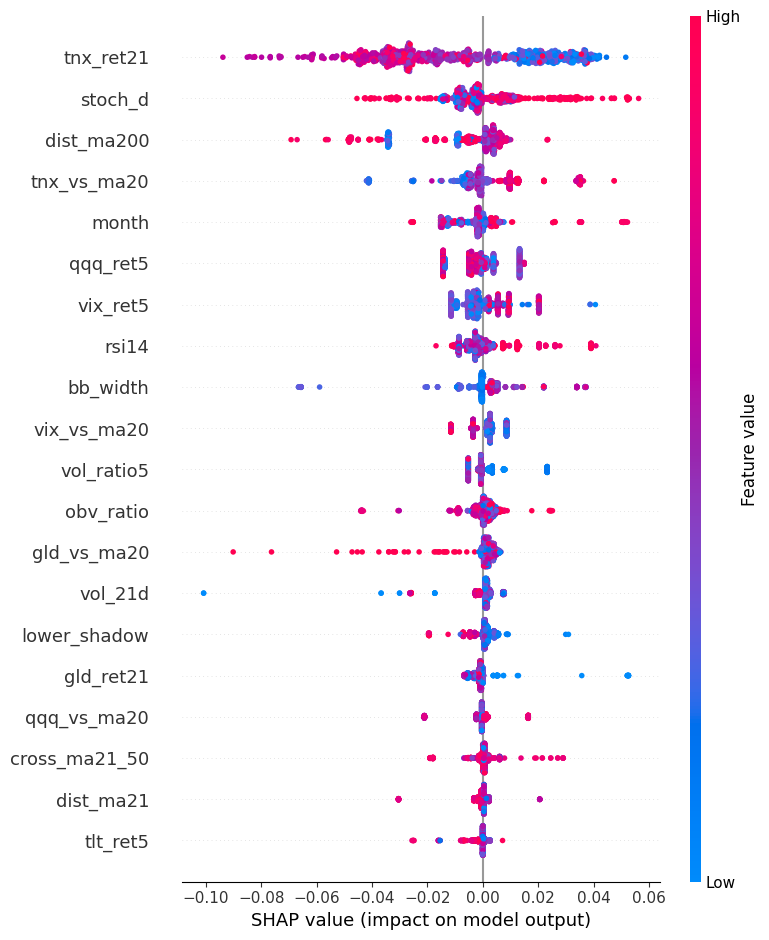

In [37]:
# ── BLOCK 10 [OPT]: SHAP FEATURE SELECTION ────────────────────────────────────
# pip install shap
import shap

explainer   = shap.TreeExplainer(model)
shap_vals   = explainer.shap_values(X_test)
sv          = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=X.columns).sort_values(ascending=False)
top_feats = mean_shap[mean_shap > 0.001].index.tolist()
print(f"Features SHAP-selected: {len(top_feats)} / {X.shape[1]}")

# Retrain con subset
model_shap = lgb.LGBMClassifier(**BEST_PARAMS)
model_shap.fit(
    X_train[top_feats], y_train,
    eval_set=[(X_test[top_feats], y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
prob_up_shap = model_shap.predict_proba(X_test[top_feats])[:, 1]
# → sostituisci prob_up con prob_up_shap nei blocchi successivi

shap.summary_plot(sv[:1000], X_test.iloc[:1000], max_display=20)


In [38]:
# ── BLOCK 11 [OPT]: WALK-FORWARD VALIDATION ───────────────────────────────────
TRAIN_YRS, TEST_MONTHS = 5, 6
results_wf = []
start_pos  = 0

while True:
    train_end = dates[start_pos] + pd.DateOffset(years=TRAIN_YRS)
    test_end  = train_end + pd.DateOffset(months=TEST_MONTHS)
    if test_end > dates[-1]:
        break

    tr_mask = (dates >= dates[start_pos]) & (dates < train_end)
    te_mask = (dates >= train_end)        & (dates < test_end)
    if tr_mask.sum() < 500 or te_mask.sum() < 20:
        start_pos += 1; continue

    mdl_wf = lgb.LGBMClassifier(**BEST_PARAMS)
    mdl_wf.fit(X[tr_mask], y[tr_mask], callbacks=[lgb.log_evaluation(-1)])

    prob_wf = mdl_wf.predict_proba(X[te_mask])[:, 1]
    M_wf, *_ = backtest(prob_wf, df.loc[dates[te_mask], 'Close'], CONF)
    M_wf['fold_start'] = str(train_end.date())
    results_wf.append(M_wf)

    nxt = dates[dates >= test_end]
    if len(nxt) == 0: break
    start_pos = np.where(dates == nxt[0])[0][0]

df_wf = pd.DataFrame(results_wf)
cols  = ['fold_start', 'Sharpe Strategy', 'Sharpe B&H', 'MDD Strategy', 'Hit Rate', 'Pct Invested']
print(df_wf[cols].to_string(index=False))
print(f"\nMean Sharpe — Strategy: {df_wf['Sharpe Strategy'].mean():.3f} | B&H: {df_wf['Sharpe B&H'].mean():.3f}")


fold_start  Sharpe Strategy  Sharpe B&H  MDD Strategy  Hit Rate  Pct Invested
2009-12-20         0.668673    0.227222     -0.098914  0.619048      0.677419
2015-06-21         1.478108   -0.419655     -0.057351  0.505618      0.700787
2020-12-21        -0.660348    2.001462     -0.044279  0.518519      0.435484

Mean Sharpe — Strategy: 0.495 | B&H: 0.603


Best trial: 7. Best value: 1.14967:   5%|▍         | 7/150 [00:00<00:00, 175.80it/s] 

Best trial: 100. Best value: 1.4654: 100%|██████████| 150/150 [00:01<00:00, 82.09it/s]



CONF_BULL : 0.6122  (regime rialzista)
CONF_BEAR : 0.8044  (regime ribassista — più selettivo)

══════════════════════════════════════════════════════════════════════
  Variante             Return    Sharpe       MDD     %Inv   HitRate
══════════════════════════════════════════════════════════════════════
  No Filter           +81.19%    1.3217     -8.94%    42.2%    0.5858
  Hard Filter         +52.48%    1.4654     -4.80%    30.6%    0.5939
  Adaptive            +52.48%    1.4654     -4.80%    30.6%    0.5939
  Buy & Hold         +142.61%    0.7896    -33.72%    100.0%          —
══════════════════════════════════════════════════════════════════════


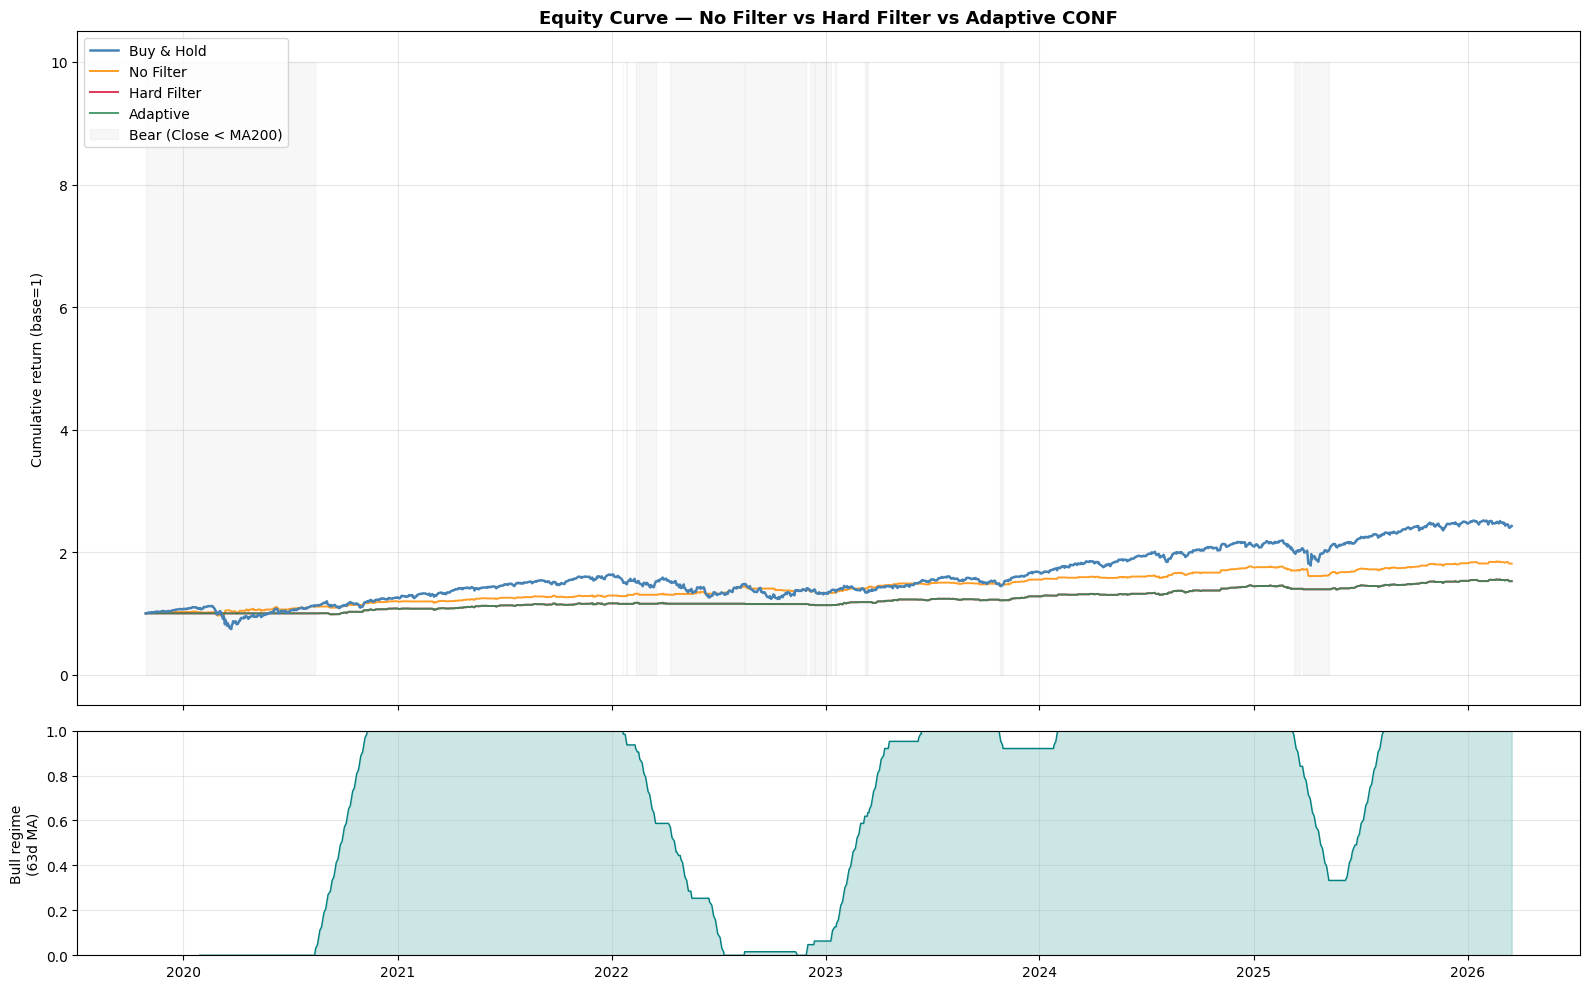

In [42]:
# ── BLOCK 12 [OPT]: REGIME FILTER + ADAPTIVE CONF ────────────────────────────
ma200_test  = df.loc[dates_test, 'Close'].rolling(200).mean()
regime_bull = (df.loc[dates_test, 'Close'] > ma200_test).values

def adaptive_strategy_metrics(prob, spy_r, bull_mask, conf_bull, conf_bear):
    conf_vec = np.where(bull_mask, conf_bull, conf_bear)
    pos      = np.where(prob > conf_vec, prob, 0.0)
    pos      = np.roll(pos, 1); pos[0] = 0.0
    sr       = pos * spy_r
    pct      = np.mean(pos > 0)
    if pct < MIN_PCT_INV:
        return -np.inf, pct
    sharpe = (np.nanmean(sr) / (np.nanstd(sr) + 1e-9)) * np.sqrt(252)
    return sharpe, pct

def conf_adaptive_objective(trial):
    cb = trial.suggest_float('conf_bull', 0.50, 0.72)
    cr = trial.suggest_float('conf_bear', 0.55, 0.85)
    if cr <= cb:
        return -np.inf
    sh, _ = adaptive_strategy_metrics(prob_up, spy_rets_arr, regime_bull, cb, cr)
    return sh

study_adaptive = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
)
study_adaptive.optimize(conf_adaptive_objective, n_trials=150, show_progress_bar=True)

CONF_BULL = study_adaptive.best_params['conf_bull']
CONF_BEAR = study_adaptive.best_params['conf_bear']
print(f"\nCONF_BULL : {CONF_BULL:.4f}  (regime rialzista)")
print(f"CONF_BEAR : {CONF_BEAR:.4f}  (regime ribassista — più selettivo)")

# ── Costruzione segnali (tutti su prob_up raw)
conf_vec_adapt          = np.where(regime_bull, CONF_BULL, CONF_BEAR)
prob_adapt              = np.where(prob_up > conf_vec_adapt, prob_up, 0.0)

prob_hard               = prob_up.copy()
prob_hard[~regime_bull] = 0.0

# ── Backtest 3 varianti
labels = {
    'No Filter'   : (prob_up,    CONF),
    'Hard Filter' : (prob_hard,  CONF),
    'Adaptive'    : (prob_adapt, 0.0),
}

print("\n" + "═"*70)
print(f"  {'Variante':<16} {'Return':>10} {'Sharpe':>9} {'MDD':>9} {'%Inv':>8} {'HitRate':>9}")
print("═"*70)
results_regime = {}
for label, (p, c) in labels.items():
    M_r, eq_r, eq_b, *_ = backtest(p, close_test, c)
    results_regime[label] = (M_r, eq_r)
    print(
        f"  {label:<16}"
        f"  {M_r['Return Strategy']:>+9.2%}"
        f"  {M_r['Sharpe Strategy']:>8.4f}"
        f"  {M_r['MDD Strategy']:>+9.2%}"
        f"  {M_r['Pct Invested']:>7.1%}"
        f"  {M_r['Hit Rate']:>8.4f}"
    )
print(f"  {'Buy & Hold':<16}"
      f"  {M['Return B&H']:>+9.2%}"
      f"  {M['Sharpe B&H']:>8.4f}"
      f"  {M['MDD B&H']:>+9.2%}"
      f"  {'100.0%':>8}"
      f"  {'—':>9}")
print("═"*70)

# ── Plot confronto equity curve
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
td = pd.to_datetime(dates_test)

axes[0].plot(td, eq_b, lw=1.8, color='steelblue', label='Buy & Hold', zorder=3)
palette = {'No Filter': 'darkorange', 'Hard Filter': 'crimson', 'Adaptive': 'seagreen'}
for label, (_, eq_r) in results_regime.items():
    axes[0].plot(td, eq_r, lw=1.4, color=palette[label], label=label, alpha=0.85)

axes[0].fill_between(td, 0, 10, where=~regime_bull,
                     alpha=0.06, color='gray', label='Bear (Close < MA200)')
axes[0].set_title('Equity Curve — No Filter vs Hard Filter vs Adaptive CONF',
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel('Cumulative return (base=1)')
axes[0].legend(loc='upper left'); axes[0].grid(alpha=0.3)

bull_roll = pd.Series(regime_bull.astype(float), index=td).rolling(63).mean()
axes[1].plot(td, bull_roll, color='teal', lw=1)
axes[1].fill_between(td, 0, bull_roll, alpha=0.2, color='teal')
axes[1].set_ylabel('Bull regime\n(63d MA)')
axes[1].set_ylim(0, 1)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('spy_regime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Training modelli per orizzonte:
  ✓  7d  |  samples: 5343  |  baseline: 61.2%
  ✓ 14d  |  samples: 5343  |  baseline: 65.6%
  ✓ 21d  |  samples: 5343  |  baseline: 66.9%

════════════════════════════════════════════════════════════
  LIVE PREDICTION  —  dati al Tuesday 17 March 2026
  Segnale da eseguire: domani all'apertura mercato (NYSE)
════════════════════════════════════════════════════════════
  SPY Close : 670.79   MA200 : 657.27   Regime : 🟢 BULL
  CONF threshold : 0.6122
────────────────────────────────────────────────────────────
  Orizzonte        P(up)  Barra                 Position  Azione
────────────────────────────────────────────────────────────
   7d forward     11.4%  ██░░░░░░░░░░░░░░░░░░     0.0%   FLAT  
  14d forward     11.9%  ██░░░░░░░░░░░░░░░░░░     0.0%   FLAT  
  21d forward      8.8%  █░░░░░░░░░░░░░░░░░░░     0.0%   FLAT  
════════════════════════════════════════════════════════════


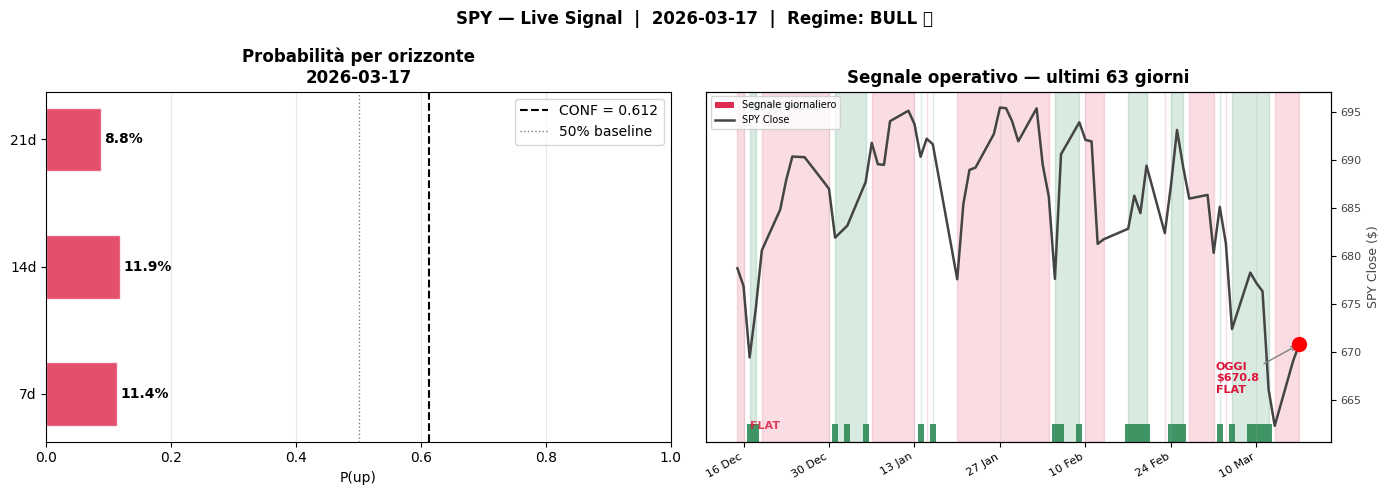

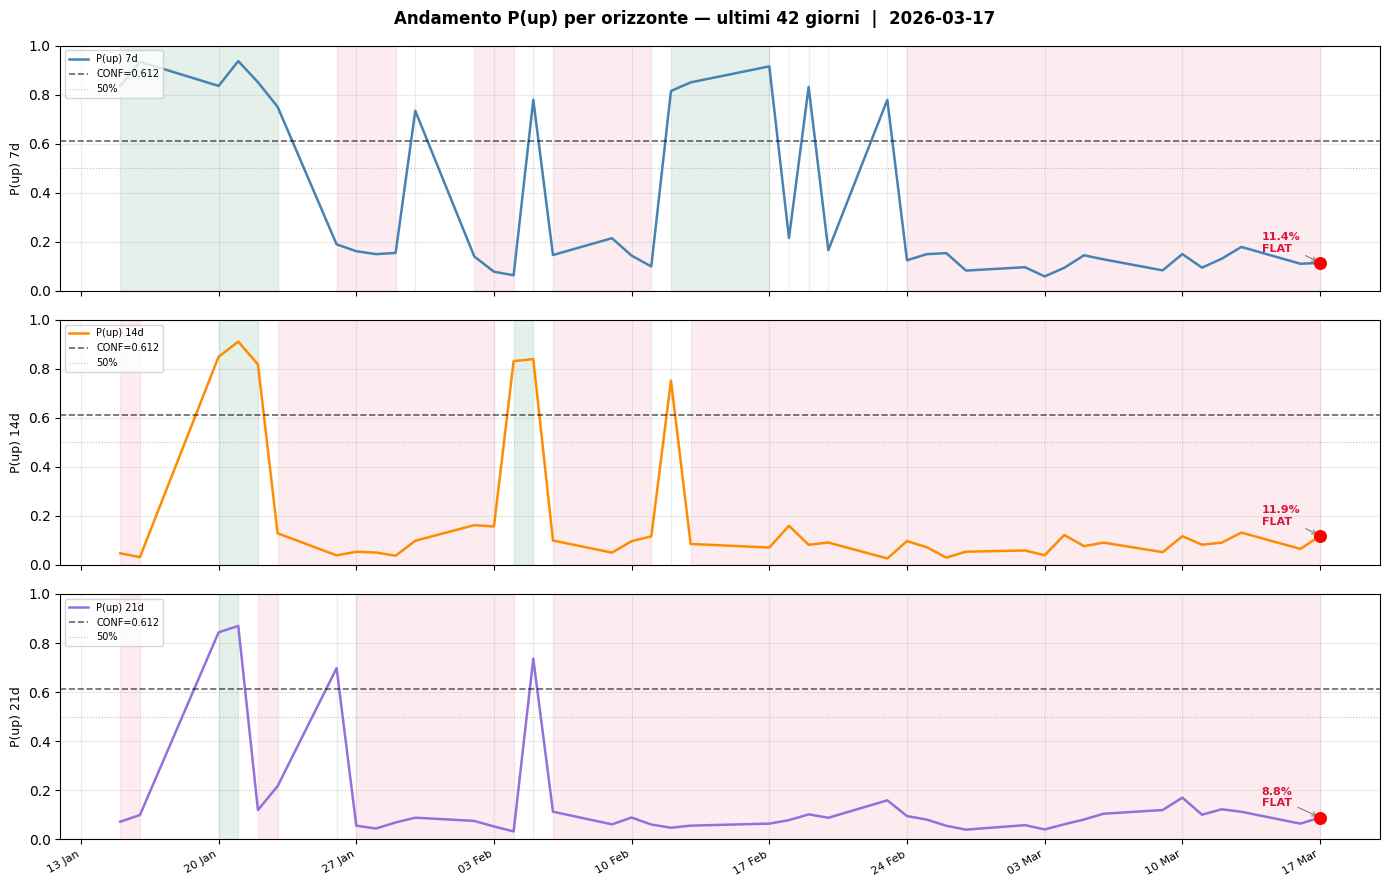

In [48]:
# ── BLOCK 14: LIVE PREDICTION — 7 / 14 / 21 DAY SIGNAL ──────────────────────
HORIZONS = [7, 14, 21]

features_full = compute_features(df).dropna()
feat_cols     = X.columns.tolist()
features_full = features_full[feat_cols]

models_h = {}
print("Training modelli per orizzonte:")
for h in HORIZONS:
    tgt_h  = (df['Close'].pct_change(h).shift(-h) > 0).astype(int)
    data_h = features_full.join(tgt_h.rename('target')).dropna()
    X_h    = data_h[feat_cols]
    y_h    = data_h['target']
    mdl_h  = lgb.LGBMClassifier(**BEST_PARAMS)
    mdl_h.fit(X_h, y_h, callbacks=[lgb.log_evaluation(-1)])
    models_h[h] = mdl_h
    print(f"  ✓ {h:>2}d  |  samples: {len(X_h)}  |  baseline: {y_h.mean():.1%}")

last_row  = features_full.iloc[[-1]]
last_date = features_full.index[-1]

close_now = df['Close'].iloc[-1]
ma200_now = df['Close'].rolling(200).mean().iloc[-1]
bull_now  = close_now > ma200_now

preds = {}
for h in HORIZONS:
    prob_h = models_h[h].predict_proba(last_row)[0, 1]
    if not bull_now:
        action, size = 'FLAT', 0.0
    elif prob_h > CONF:
        action, size = 'BUY / HOLD', prob_h
    else:
        action, size = 'FLAT', 0.0
    preds[h] = {'prob': prob_h, 'action': action, 'size': size}

print(f"\n{'═'*60}")
print(f"  LIVE PREDICTION  —  dati al {last_date.strftime('%A %d %B %Y')}")
print(f"  Segnale da eseguire: domani all'apertura mercato (NYSE)")
print(f"{'═'*60}")
print(f"  SPY Close : {close_now:.2f}   MA200 : {ma200_now:.2f}   "
      f"Regime : {'🟢 BULL' if bull_now else '🔴 BEAR (regime filter attivo)'}")
print(f"  CONF threshold : {CONF:.4f}")
print(f"{'─'*60}")
print(f"  {'Orizzonte':<14} {'P(up)':>7}  {'Barra':20}  {'Position':>8}  Azione")
print(f"{'─'*60}")
for h, d in preds.items():
    bar  = '█' * int(d['prob'] * 20) + '░' * (20 - int(d['prob'] * 20))
    flag = '◀ CONF' if d['prob'] > CONF else ''
    print(f"  {h:>2}d forward    {d['prob']:>6.1%}  {bar}  {d['size']:>7.1%}   {d['action']}  {flag}")
print(f"{'═'*60}")

# ── FIGURA 1: gauge orizzonti + segnale operativo ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

horizons_labels = [f"{h}d" for h in HORIZONS]
probs           = [preds[h]['prob'] for h in HORIZONS]
colors          = ['seagreen' if preds[h]['action'] != 'FLAT' else 'crimson' for h in HORIZONS]

bars = axes[0].barh(horizons_labels, probs, color=colors, alpha=0.75, edgecolor='white', height=0.5)
axes[0].axvline(CONF, color='black', lw=1.5, ls='--', label=f'CONF = {CONF:.3f}')
axes[0].axvline(0.5,  color='gray',  lw=1.0, ls=':',  label='50% baseline')
for bar, prob in zip(bars, probs):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{prob:.1%}', va='center', fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('P(up)')
axes[0].set_title(f'Probabilità per orizzonte\n{last_date.strftime("%Y-%m-%d")}',
                  fontweight='bold')
axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)

# ── Subplot destro: sfondo segnale + SPY price + punto oggi
N = 63
recent_dates = pd.to_datetime(dates_test[-N:])
recent_probs = prob_up[-N:]
recent_close = df.loc[dates_test[-N:], 'Close'].values

ax_prob  = axes[1]
ax_price = ax_prob.twinx()

ax_prob.fill_between(recent_dates, 0, 1,
    where=(recent_probs > CONF), alpha=0.18, color='seagreen', label='_nolegend_')
ax_prob.fill_between(recent_dates, 0, 1,
    where=(recent_probs <= CONF), alpha=0.14, color='crimson', label='_nolegend_')
ax_prob.text(recent_dates[2], 0.97, 'BUY / HOLD',
             color='seagreen', fontsize=8, va='top',    alpha=0.8, fontweight='bold')
ax_prob.text(recent_dates[2], 0.03, 'FLAT',
             color='crimson',  fontsize=8, va='bottom', alpha=0.8, fontweight='bold')

signal_bar = np.where(recent_probs > CONF, 1, 0)
ax_prob.bar(recent_dates, signal_bar * 0.05, bottom=0,
            color=['seagreen' if s else 'crimson' for s in signal_bar],
            width=1.0, alpha=0.9, label='Segnale giornaliero')

ax_price.plot(recent_dates, recent_close,
              color='#444444', lw=1.8, label='SPY Close')
ax_price.set_ylabel('SPY Close ($)', color='#444444', fontsize=9)
ax_price.tick_params(axis='y', labelcolor='#444444', labelsize=8)

today_prob   = preds[7]['prob']
today_action = preds[7]['action']
today_close  = recent_close[-1]
ax_price.scatter([recent_dates[-1]], [today_close], color='red', zorder=6, s=100)
ax_price.annotate(
    f"OGGI\n${today_close:.1f}\n{today_action}",
    xy=(recent_dates[-1], today_close),
    xytext=(-60, -35), textcoords='offset points',
    fontsize=8, fontweight='bold',
    color='seagreen' if today_action != 'FLAT' else 'crimson',
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.0)
)

ax_prob.set_ylim(0, 1); ax_prob.set_yticks([])
ax_prob.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_prob.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax_prob.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

lines1, labels1 = ax_prob.get_legend_handles_labels()
lines2, labels2 = ax_price.get_legend_handles_labels()
ax_prob.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')
ax_prob.grid(alpha=0.20)
ax_prob.set_title('Segnale operativo — ultimi 63 giorni', fontweight='bold')

fig.suptitle(
    f"SPY — Live Signal  |  {last_date.strftime('%Y-%m-%d')}  |  "
    f"Regime: {'BULL 🟢' if bull_now else 'BEAR 🔴'}",
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig('spy_live_signal.png', dpi=150, bbox_inches='tight')
plt.show()

# ── FIGURA 2: andamento P(up) per i 3 orizzonti — ultimi 42 giorni ───────────
N2          = 42
recent_rows = features_full.iloc[-N2:]
recent_d2   = pd.to_datetime(recent_rows.index)

probs_h = {}
for h in HORIZONS:
    probs_h[h] = models_h[h].predict_proba(recent_rows)[:, 1]

fig2, axes2 = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
palette_h   = {7: 'steelblue', 14: 'darkorange', 21: 'mediumpurple'}

for i, h in enumerate(HORIZONS):
    ax = axes2[i]
    ph = probs_h[h]

    ax.fill_between(recent_d2, 0, 1,
        where=(ph > CONF), alpha=0.12, color='seagreen')
    ax.fill_between(recent_d2, 0, 1,
        where=(ph <= CONF), alpha=0.08, color='crimson')

    ax.plot(recent_d2, ph, color=palette_h[h], lw=1.8, label=f'P(up) {h}d')
    ax.axhline(CONF, color='black', lw=1.2, ls='--', alpha=0.6, label=f'CONF={CONF:.3f}')
    ax.axhline(0.50, color='gray',  lw=0.8, ls=':',  alpha=0.5, label='50%')

    ax.scatter([recent_d2[-1]], [ph[-1]], color='red', zorder=5, s=70)
    ax.annotate(
        f"{ph[-1]:.1%}\n{'BUY' if preds[h]['action'] != 'FLAT' else 'FLAT'}",
        xy=(recent_d2[-1], ph[-1]),
        xytext=(-42, 8), textcoords='offset points',
        fontsize=8, fontweight='bold',
        color='seagreen' if preds[h]['action'] != 'FLAT' else 'crimson',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel(f'P(up) {h}d', fontsize=9)
    ax.legend(loc='upper left', fontsize=7)
    ax.grid(alpha=0.25)

axes2[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes2[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(axes2[-1].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

fig2.suptitle(
    f"Andamento P(up) per orizzonte — ultimi {N2} giorni  |  {last_date.strftime('%Y-%m-%d')}",
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig('spy_horizons_probs.png', dpi=150, bbox_inches='tight')
plt.show()
